# Multi-UAV Swarm Trajectory Planning

**Pipeline overview**

| Cell | Stage | Modules |
|------|-------|---------|
| 1 | Environment setup & validation | `environment`, `visualizer_static` |
| 2 | Global path planning (A\*) | `global_planner` |
| 3 | Safe corridor extraction | `safe_corridor` |
| 4 | Individual trajectory generation (STO) | `trajectory_generator` |
| 5 | Conflict detection | `conflict_resolver` |
| 6 | Conflict resolution & replanning | `conflict_resolver` |
| 7 | Static 3-D visualisation | `visualizer_static` |
| 8 | Web simulation (HTML export) | `visualizer_web` |

In [1]:
# ── Cell 1 — Environment + Fleet setup ──────────────────────────────────────
import os, sys, logging, yaml

# ── sys.path setup ────────────────────────────────────────────────────────────
_SWARM_DIR  = os.path.abspath('')          # …/uavsafeplanning/SWARM
_PARENT_DIR = os.path.dirname(_SWARM_DIR)  # …/uavsafeplanning
for _p in (_SWARM_DIR, _PARENT_DIR):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Imports ───────────────────────────────────────────────────────────────────
from environment       import Environment, ConfigValidationError
from uav               import Fleet
from visualizer_static import plot_environment_3d

# Silence sub-module DEBUG/INFO — only warnings/errors reach the output.
# Must come AFTER imports so the handlers are already registered.
for _mod in ('environment', 'uav'):
    logging.getLogger(_mod).setLevel(logging.WARNING)

# ── Config paths ──────────────────────────────────────────────────────────────
SIM_CONFIG   = os.path.join(_SWARM_DIR, 'configs', 'simulation.yaml')
FLEET_CONFIG = os.path.join(_SWARM_DIR, 'configs', 'fleet.yaml')

# ── Read which environment to use from simulation.yaml ────────────────────────
with open(SIM_CONFIG, 'r') as f:
    sim_cfg = yaml.safe_load(f)
    env_filename = sim_cfg.get('environment', 'environment.yaml')  # default fallback

ENV_CONFIG = os.path.join(_SWARM_DIR, 'configs', env_filename)
print(f"Using environment: {env_filename}")

def _tag(ok): return '✓' if ok else '✗'

# ── Environment ───────────────────────────────────────────────────────────────
try:
    env        = Environment.from_yaml(ENV_CONFIG)
    voxel_grid = env.to_voxel_grid()   # cached — A* (Cell 2) reuses this
    w = env.world
    print(f"✓  Environment  [{os.path.basename(ENV_CONFIG)}]  "
          f"{len(env.cylinders)} cylinders · {len(env.walls)} walls · "
          f"grid {w.nx}×{w.ny}×{w.nz}")
except ConfigValidationError as exc:
    print(f"✗  Environment  [{os.path.basename(ENV_CONFIG)}]  FAILED → {exc}")
    raise

# ── Fleet ─────────────────────────────────────────────────────────────────────
try:
    fleet = Fleet.from_yaml(FLEET_CONFIG)
    ids   = ', '.join(u.id for u in fleet.uavs)
    print(f"✓  Fleet        [{os.path.basename(FLEET_CONFIG)}]  "
          f"{len(fleet.uavs)} UAVs  ({ids})")
except ConfigValidationError as exc:
    print(f"✗  Fleet        [{os.path.basename(FLEET_CONFIG)}]  FAILED → {exc}")
    raise

# ── Position validation ───────────────────────────────────────────────────────
try:
    fleet.validate_with_environment(env)
    print("✓  Positions    all start / goal positions are obstacle-free")
except ConfigValidationError as exc:
    print(f"✗  Positions    FAILED → {exc}")
    raise

# ── Visualisation ─────────────────────────────────────────────────────────────
plot_environment_3d(env, fleet=fleet)


Using environment: environment_hard.yaml
✓  Environment  [environment_hard.yaml]  30 cylinders · 2 walls · grid 200×200×40
✓  Fleet        [fleet.yaml]  3 UAVs  (uav_0, uav_1, uav_2)
✓  Positions    all start / goal positions are obstacle-free


In [2]:
# ── Cell 2 — Global Path Planning (A*) ──────────────────────────────────────
from global_planner import plan_paths, PlanResult, PlannerConfig
import logging
logging.getLogger("global_planner").setLevel(logging.WARNING)

PLANNER_CONFIG = os.path.join(_SWARM_DIR, "configs", "planner.yaml")

# ── Load planner config ───────────────────────────────────────────────────────
try:
    planner_cfg = PlannerConfig.from_yaml(PLANNER_CONFIG)
    w = env.world
    print(f"✓  Planner      [{os.path.basename(PLANNER_CONFIG)}]  "
          f"connectivity={planner_cfg.connectivity}  clearance={planner_cfg.clearance} voxel  "
          f"inflation={planner_cfg.inflation_radius} m")
except Exception as exc:
    print(f"✗  Planner      [{os.path.basename(PLANNER_CONFIG)}]  FAILED → {exc}")
    raise

# ── Apply obstacle inflation (rebuilds voxel grid if radius changed) ──────────
env.inflation_radius = planner_cfg.inflation_radius

# ── Run A* for all UAVs ───────────────────────────────────────────────────────
print(f"Running A* for {len(fleet.uavs)} UAVs  "
      f"(grid {env.world.nx}×{env.world.ny}×{env.world.nz})")

try:
    paths = plan_paths(env, fleet,
                       connectivity=planner_cfg.connectivity,
                       clearance=planner_cfg.clearance)
    for pr in paths:
        print(f"  ✓  {pr.uav_id:<10}  A*: {pr.n_astar_nodes:4d} nodes  "
              f"→  LOS: {pr.n_waypoints} waypoints  →  {pr.path_length:.1f} m")
except RuntimeError as exc:
    print(f"  ✗  A* FAILED — {exc}")
    raise

# ── Visualisation — same scene as Cell 1 + pruned paths ──────────────────────
plot_environment_3d(env, fleet=fleet, paths=paths)

✓  Planner      [planner.yaml]  connectivity=18  clearance=0 voxel  inflation=0.5 m
Running A* for 3 UAVs  (grid 200×200×40)
  ✓  uav_0       A*:  183 nodes  →  LOS: 7 waypoints  →  117.8 m
  ✓  uav_1       A*:  171 nodes  →  LOS: 5 waypoints  →  85.7 m
  ✓  uav_2       A*:  182 nodes  →  LOS: 6 waypoints  →  117.8 m


In [3]:
# ── Cell 3 — Safe Corridor Extraction ────────────────────────────────────────
from safe_corridor import extract_corridors, CorridorResult
import logging
logging.getLogger("safe_corridor").setLevel(logging.WARNING)

BOX_HE = planner_cfg.box_half_extents   # loaded from planner.yaml

print(f"Extracting safe corridors  "
      f"(seed box: {BOX_HE[0]} × {BOX_HE[1]} × {BOX_HE[2]} m)")

try:
    corridors = extract_corridors(env, paths, box_half_extents=BOX_HE)
    for cr in corridors:
        n     = len(cr.A_list)
        avg_c = (sum(cr.A_list[i].shape[0] for i in range(n)) / n) if n else 0
        print(f"  ✓  {cr.uav_id:<10}  {n} corridor{'s' if n != 1 else ' '}  "
              f"({avg_c:.0f} constraints/corridor avg)")
except RuntimeError as exc:
    print(f"  ✗  FAILED — {exc}")
    raise

# ── Visualisation — environment + paths + safe corridors ─────────────────────
plot_environment_3d(env, fleet=fleet, paths=paths, corridors=corridors)

Extracting safe corridors  (seed box: 5.0 × 5.0 × 5.0 m)
  ✓  uav_0       6 corridors  (11 constraints/corridor avg)
  ✓  uav_1       4 corridors  (10 constraints/corridor avg)
  ✓  uav_2       5 corridors  (12 constraints/corridor avg)


In [4]:
# ── Cell 4 — Trajectory Generation (STO) ────────────────────────────────────
from trajectory_generator import generate_trajectories, TrajectoryResult, STOConfig
import logging
logging.getLogger("trajectory_generator").setLevel(logging.WARNING)

sto_cfg = STOConfig.from_yaml(PLANNER_CONFIG)
print(f"✓  STO config   [{os.path.basename(PLANNER_CONFIG)}]  "
      f"max_iter={sto_cfg.max_iter}  adaptive={sto_cfg.adaptive_weights}  "
      f"cost={sto_cfg.corridor_cost_type.upper()}")

# ── Optimise trajectories (runs STO per UAV) ─────────────────────────────────
try:
    trajectories = generate_trajectories(fleet, paths, corridors, sto_cfg, verbose=True)
except RuntimeError as exc:
    print(f"\n✗  STO FAILED — {exc}")
    raise

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*62}")
for tr in trajectories:
    print(f"  ✓  {tr.uav_id:<10}  "
          f"T={tr.total_time:.1f} s  "
          f"max_v={tr.vel_norm.max():.2f} m/s  "
          f"jerk={tr.jerk_cost:.4f}  "
          f"viol_corr={tr.violations['corridor']:.4f}  "
          f"({tr.runtime:.0f} s)")
print(f"{'─'*62}")

# ── Visualisation — environment + paths + corridors + trajectories ────────────
plot_environment_3d(env, fleet=fleet, paths=paths, corridors=corridors,
                    trajectories=trajectories)

✓  STO config   [planner.yaml]  max_iter=50  adaptive=True  cost=L2

──────────────────────────────────────────────────────────────
  STO  ▶  uav_0   (6 segments,  5 waypoints)
──────────────────────────────────────────────────────────────


/home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/STO_Swarm/sto_swarm_planner.py:187: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.waypoints = torch.tensor(


STO TRAJECTORY OPTIMIZATION
Segments:       6
Waypoints:      5
Max iterations: 50
Corridor cost:  L2 penalty
Adaptive weights: ON  (3 phases, ×5.0 per phase)

Objective weights (fixed):
  λ_jerk     = 10.00
  λ_time     = 0.05

Constraint weights (phase 1 / final target):
  λ_vel      = 4.80  →  120.00
  λ_acc      = 0.20  →  5.00
  λ_corridor = 40.00  →  1000.00  [L2]

Iter | Phase |        Total |       Jerk |     Time |        Vel |        Acc |       Corr
--------------------------------------------------------------------------------------------------
   1 |     1 |    37.692165 |   3.124015 |    27.30 |   0.430169 |   0.000000 |   0.075557
   5 |     1 |     3.455626 |   0.060682 |    56.84 |   0.000000 |   0.000000 |   0.000170
  10 |     1 |     3.455626 |   0.060682 |    56.84 |   0.000000 |   0.000000 |   0.000170
  15 |     1 |     3.455626 |   0.060682 |    56.84 |   0.000000 |   0.000000 |   0.000170

  ── Phase 2/3: λ_vel=24.0  λ_acc=1.0  λ_corridor=200.0  (L-BFGS reset)

OK  Conflict detector  [planner.yaml]  safety_margin=9.000 m  dt_sample=50 ms

──────────────────────────────────────────────────────────────────────
  SPACE-TIME CONFLICT DETECTION REPORT
──────────────────────────────────────────────────────────────────────
  Safety margin (extra)   : 9.000 m  (threshold = r_i + r_j + margin)
  Time-grid resolution    : 50 ms
──────────────────────────────────────────────────────────────────────
  !!  1 violation(s) detected:

     +-- uav_0  <->  uav_2
     |  safety threshold : 10.000 m
     |  window           : [25.700 s -> 36.150 s]  (dt = 10.450 s)
     |  closest approach : 2.2593 m  at t = 31.750 s
     |  pos A            : [48.88, 49.41, 5.25]
     +  pos B            : [50.76, 50.66, 5.25]

──────────────────────────────────────────────────────────────────────
  Corridor polytope spatial intersections : 17
  -> with simultaneous temporal overlap   : 10

  [!] [uav_0 P1] x [uav_1 P0]   A:[12.93-28.70 s]   B:[0.00-26.76 s]  <- SPATIO-TEMPORA

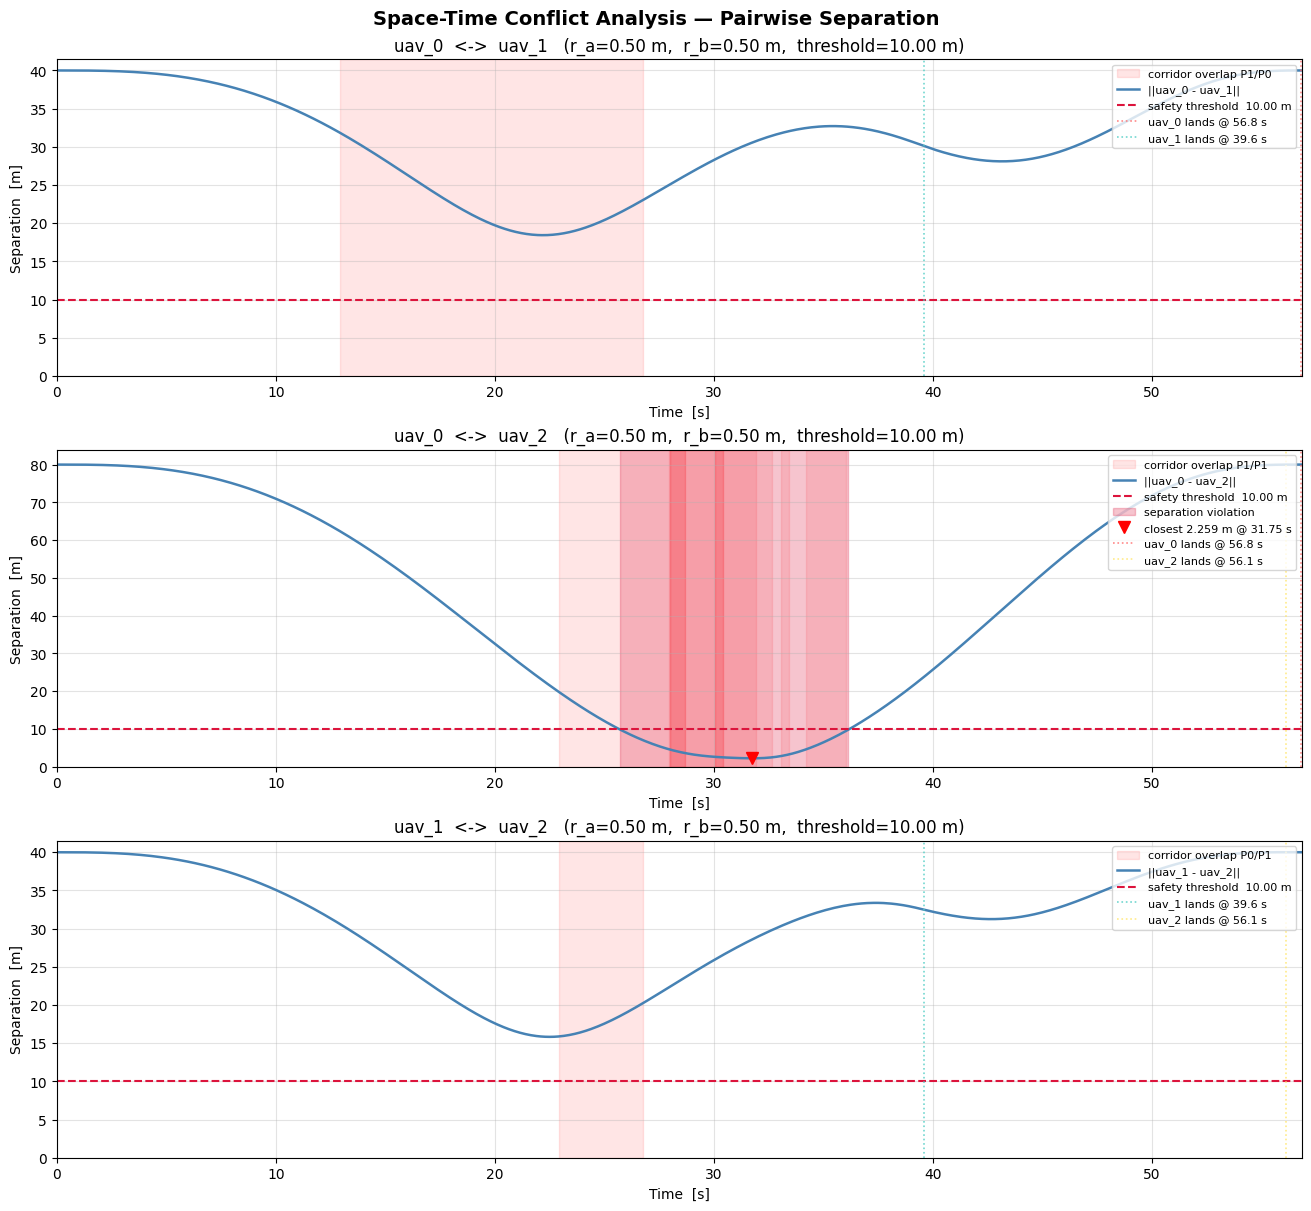

In [5]:
# ── Cell 5 — Space-Time Conflict Detection ───────────────────────────────────
from conflict_detector import (
    ConflictDetectorConfig,
    detect_conflicts,
    plot_conflict_report,
)
import logging
logging.getLogger("conflict_detector").setLevel(logging.WARNING)

# ── Load config from planner.yaml (conflict_detection: block) ────────────────
cd_cfg = ConflictDetectorConfig.from_yaml(PLANNER_CONFIG)
print(
    f"OK  Conflict detector  [{os.path.basename(PLANNER_CONFIG)}]  "
    f"safety_margin={cd_cfg.safety_margin:.3f} m  "
    f"dt_sample={cd_cfg.dt_sample * 1000:.0f} ms"
)

# ── Run detection ─────────────────────────────────────────────────────────────
conflict_report = detect_conflicts(
    fleet        = fleet,
    trajectories = trajectories,
    corridors    = corridors,
    cfg          = cd_cfg,
)

# ── Report ────────────────────────────────────────────────────────────────────
print()
print(conflict_report.summary())

# ── Visualisation ─────────────────────────────────────────────────────────────
plot_conflict_report(
    report       = conflict_report,
    fleet        = fleet,
    trajectories = trajectories,
)

In [6]:
# ── Cell 6 — Trajectory Simulation (Animated HTML) ───────────────────────────
from visualizer_simulation import SimulationConfig, simulate_trajectories
import logging
logging.getLogger("visualizer_simulation").setLevel(logging.WARNING)

SIM_CONFIG = os.path.join(_SWARM_DIR, "configs", "simulation.yaml")

# ── Load simulation config ────────────────────────────────────────────────────
sim_cfg = SimulationConfig.from_yaml(SIM_CONFIG)
print(
    f"OK  Simulation config  [{os.path.basename(SIM_CONFIG)}]\n"
    f"    dt={sim_cfg.dt * 1000:.0f} ms  "
    f"trail={sim_cfg.trail_length:.1f} s  "
    f"drone_size={sim_cfg.drone_size} px  "
    f"frame_duration={sim_cfg.frame_duration_ms} ms"
)

import numpy as np
t_max    = max(tr.total_time for tr in trajectories)
n_frames = len(np.arange(0.0, t_max + sim_cfg.dt, sim_cfg.dt))
print(f"    frames={n_frames}  t_max={t_max:.1f} s  output={sim_cfg.output_html}")

# ── Build animation and export to HTML ───────────────────────────────────────
print("\nBuilding animation frames ...")
html_path = simulate_trajectories(
    env             = env,
    fleet           = fleet,
    trajectories    = trajectories,
    corridors       = corridors,
    conflict_report = conflict_report,
    cfg             = sim_cfg,
)
print(f"\nOK  Simulation exported →  {html_path}")
print("    Open the file in your browser to play the animation.")

OK  Simulation config  [simulation.yaml]
    dt=100 ms  trail=2.0 s  drone_size=10 px  frame_duration=80 ms
    frames=570  t_max=56.8 s  output=simulation.html

Building animation frames ...

OK  Simulation exported →  /home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/SWARM/simulation.html
    Open the file in your browser to play the animation.


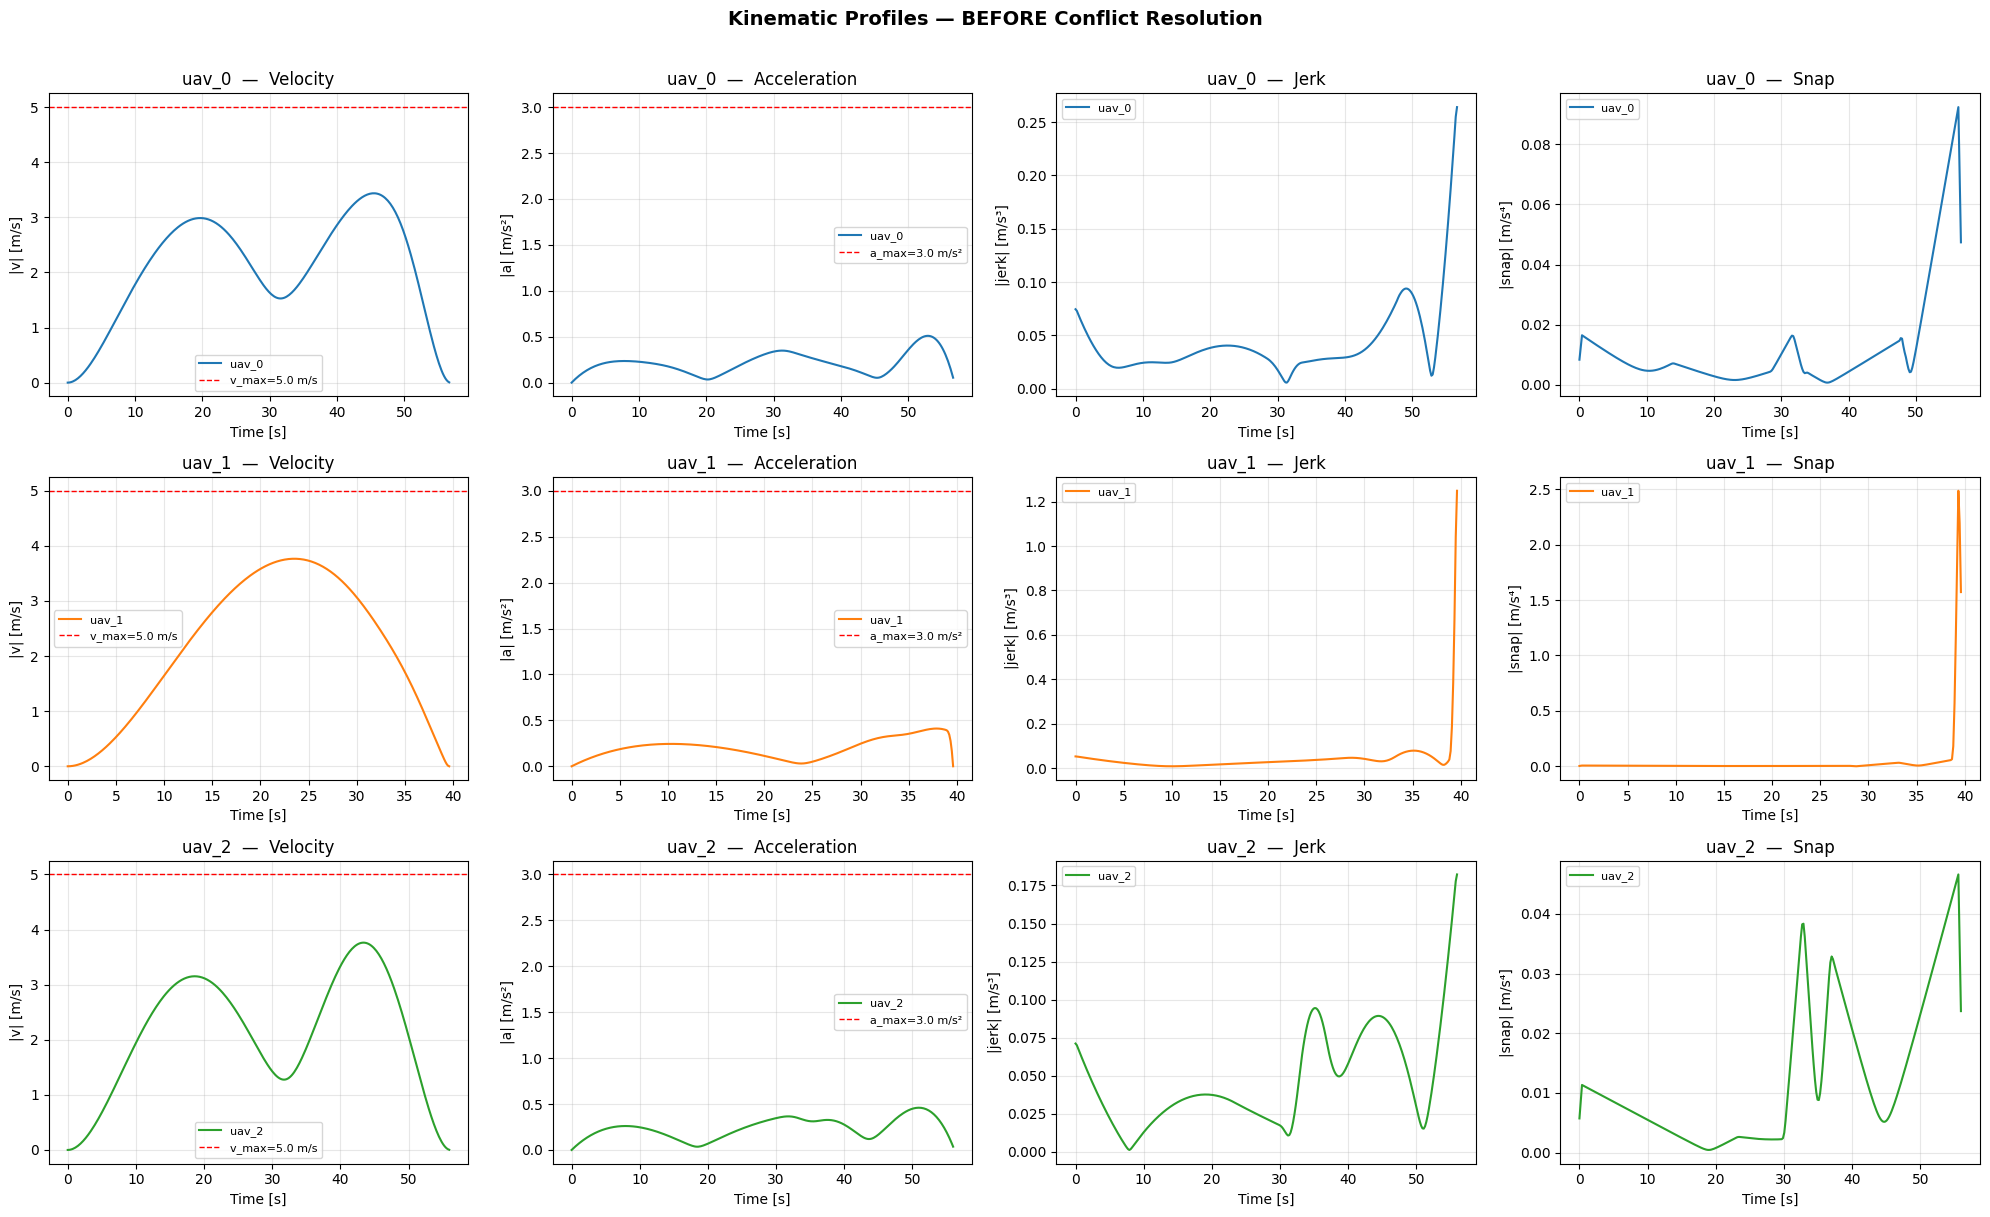


UAV             T [s]    max|v|   v_max    max|a|   a_max
──────────────────────────────────────────────────────────
uav_0           56.84     3.436     5.0     0.509     3.0
uav_1           39.61     3.767     5.0     0.411     3.0
uav_2           56.15     3.762     5.0     0.460     3.0


In [7]:
# ── Cell 7 — Kinematic Profiles BEFORE Conflict Resolution ───────────────────
import matplotlib.pyplot as plt
import numpy as np

def plot_kinematic_profiles(trajs, fleet, title="Kinematic Profiles"):
    """Plot velocity / acceleration / jerk / snap for every UAV."""
    n_uavs = len(fleet.uavs)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(n_uavs, 4, figsize=(20, 4 * n_uavs), squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for row, (uav, traj) in enumerate(zip(fleet.uavs, trajs)):
        t         = traj.t_eval
        vel_norm  = traj.vel_norm
        acc_norm  = np.linalg.norm(traj.acc, axis=1)
        jerk_vec  = np.gradient(traj.acc,  t, axis=0)
        jerk_norm = np.linalg.norm(jerk_vec, axis=1)
        snap_vec  = np.gradient(jerk_vec,  t, axis=0)
        snap_norm = np.linalg.norm(snap_vec, axis=1)

        c = colors[row % len(colors)]

        # ── Velocity ──────────────────────────────────────────────────────────
        ax = axes[row, 0]
        ax.plot(t, vel_norm, color=c, linewidth=1.5, label=uav.id)
        ax.axhline(uav.v_max, color="red", linestyle="--", linewidth=1,
                   label=f"v_max={uav.v_max:.1f} m/s")
        ax.fill_between(t, uav.v_max, vel_norm,
                        where=(vel_norm > uav.v_max), color="red", alpha=0.25)
        ax.set_title(f"{uav.id}  —  Velocity")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("|v| [m/s]")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # ── Acceleration ──────────────────────────────────────────────────────
        ax = axes[row, 1]
        ax.plot(t, acc_norm, color=c, linewidth=1.5, label=uav.id)
        ax.axhline(uav.a_max, color="red", linestyle="--", linewidth=1,
                   label=f"a_max={uav.a_max:.1f} m/s²")
        ax.fill_between(t, uav.a_max, acc_norm,
                        where=(acc_norm > uav.a_max), color="red", alpha=0.25)
        ax.set_title(f"{uav.id}  —  Acceleration")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("|a| [m/s²]")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # ── Jerk ──────────────────────────────────────────────────────────────
        ax = axes[row, 2]
        ax.plot(t, jerk_norm, color=c, linewidth=1.5, label=uav.id)
        ax.set_title(f"{uav.id}  —  Jerk")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("|jerk| [m/s³]")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # ── Snap ──────────────────────────────────────────────────────────────
        ax = axes[row, 3]
        ax.plot(t, snap_norm, color=c, linewidth=1.5, label=uav.id)
        ax.set_title(f"{uav.id}  —  Snap")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("|snap| [m/s⁴]")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f"\n{'UAV':<12} {'T [s]':>8} {'max|v|':>9} {'v_max':>7} {'max|a|':>9} {'a_max':>7}")
    print("─" * 58)
    for uav, traj in zip(fleet.uavs, trajs):
        acc_n = np.linalg.norm(traj.acc, axis=1)
        print(f"{uav.id:<12} {traj.total_time:>8.2f}"
              f" {traj.vel_norm.max():>9.3f} {uav.v_max:>7.1f}"
              f" {acc_n.max():>9.3f} {uav.a_max:>7.1f}")

plot_kinematic_profiles(
    trajectories, fleet,
    title="Kinematic Profiles — BEFORE Conflict Resolution"
)

OK  Replan config  [planner.yaml]
    delta_t_scale=0.3  min_delta_t=0.3 s  max_rounds=4
    λ_time_replan=0.05  replan_iter=50
    (STO + frozen pre-conflict segments — delay preserved, corridor enforced)

══════════════════════════════════════════════════════════════════════
  REPLAN ROUND 1/4  (1 violation(s) detected)
══════════════════════════════════════════════════════════════════════

  Processing 1 unique pair(s) (earliest violation first):

  Pair  uav_0 <-> uav_2
    violation window : [25.70 s → 36.15 s]  (duration = 10.45 s)
    path length      : uav_0 = 18.63 m  |  uav_2 = 17.19 m
    winner (faster)  : uav_0  →  trajectory unchanged
    loser  (slower)  : uav_2   →  Δt=3.13 s distributed across segs [0..1]  (10.45 × 0.3 = 3.13, min=0.3)
      seg 0: 23.267 s → 25.703 s  (+2.436 s)
      seg 1: 6.671 s → 7.370 s  (+0.699 s)

──────────────────────────────────────────────────────────────
  REPLAN  ▶  uav_2   (5 segments,  temporal_only=True,  λ_sep=0)
────────────────────

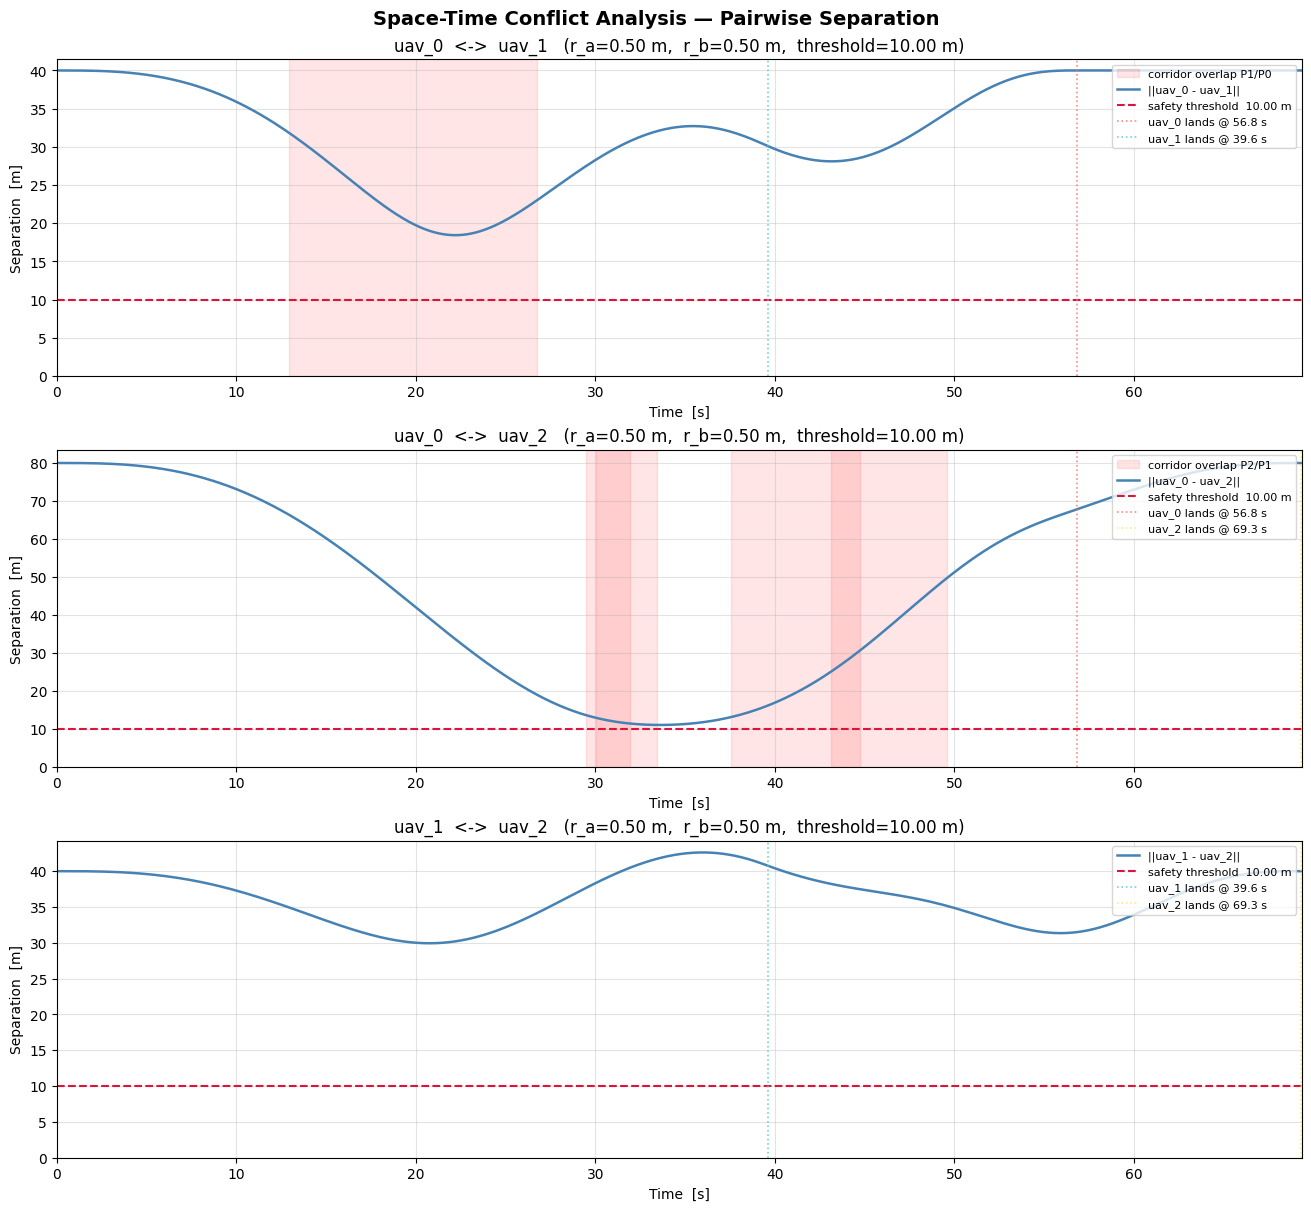

In [8]:
# ── Cell 8 — Conflict Resolution (Temporal Replanning) ───────────────────────
from conflict_resolver import ReplanConfig, resolve_conflicts
import logging
logging.getLogger("conflict_resolver").setLevel(logging.WARNING)

# ── Load replanning config ────────────────────────────────────────────────────
rp_cfg = ReplanConfig.from_yaml(PLANNER_CONFIG)
print(
    f"OK  Replan config  [{os.path.basename(PLANNER_CONFIG)}]\n"
    f"    delta_t_scale={rp_cfg.delta_t_scale}  "
    f"min_delta_t={rp_cfg.min_delta_t:.1f} s  "
    f"max_rounds={rp_cfg.max_replan_rounds}\n"
    f"    λ_time_replan={rp_cfg.lambda_time_replan}  "
    f"replan_iter={rp_cfg.replan_max_iter}\n"
    f"    (STO + frozen pre-conflict segments — delay preserved, corridor enforced)"
)

# ── Run conflict resolution ──────────────────────────────────────────────────
trajectories, conflict_report = resolve_conflicts(
    fleet           = fleet,
    trajectories    = trajectories,
    corridors       = corridors,
    plan_results    = paths,
    conflict_report = conflict_report,
    cd_cfg          = cd_cfg,
    sto_cfg         = sto_cfg,
    replan_cfg      = rp_cfg,
    verbose         = True,
)

# ── Final report ─────────────────────────────────────────────────────────────
print()
print(conflict_report.summary())

# ── Visualisation ─────────────────────────────────────────────────────────────
plot_conflict_report(conflict_report, fleet, trajectories)

# ── Updated static 3-D view ──────────────────────────────────────────────────
plot_environment_3d(env, fleet=fleet, paths=paths, corridors=corridors,
                    trajectories=trajectories)

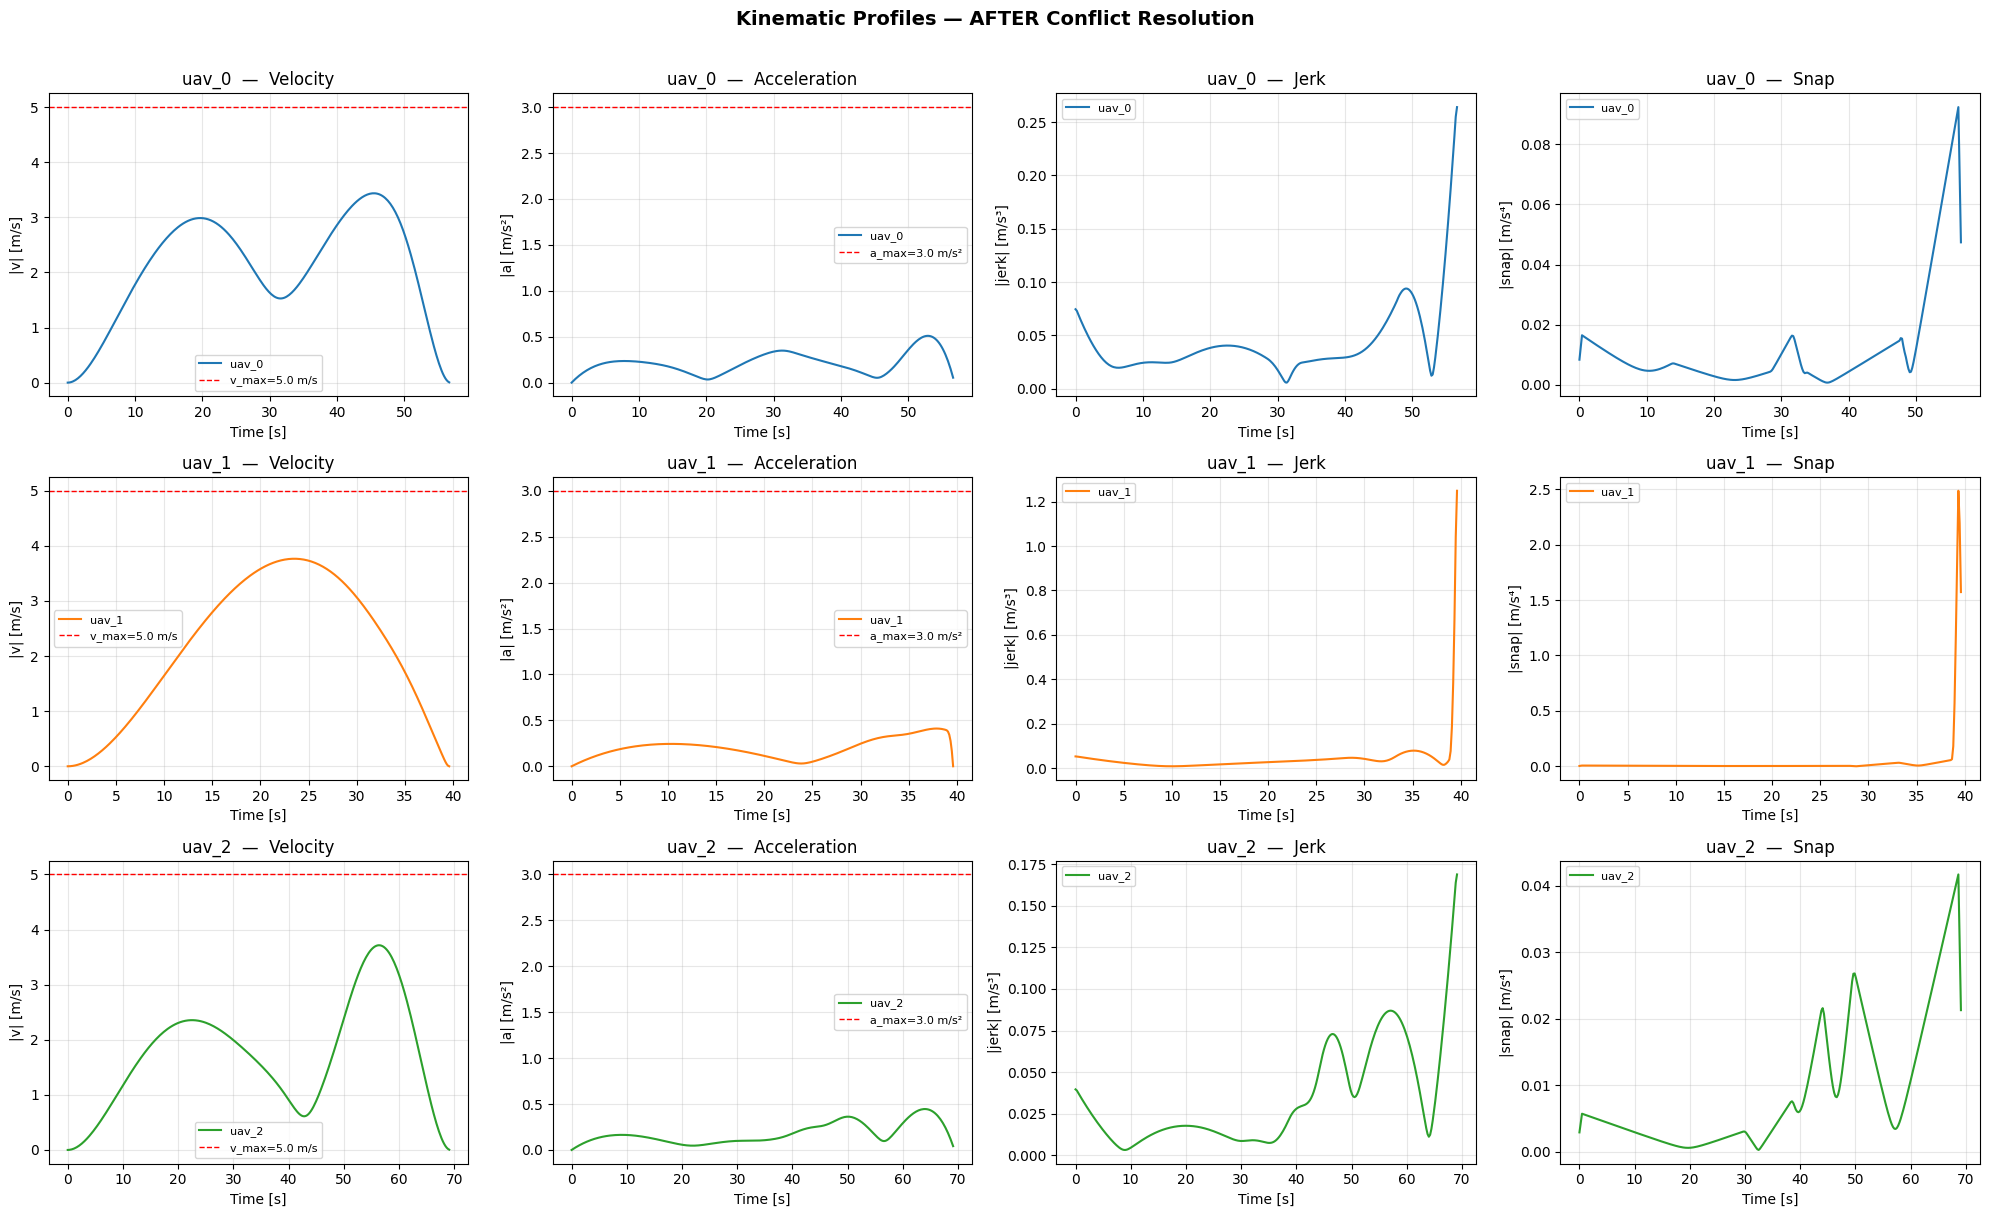


UAV             T [s]    max|v|   v_max    max|a|   a_max
──────────────────────────────────────────────────────────
uav_0           56.84     3.436     5.0     0.509     3.0
uav_1           39.61     3.767     5.0     0.411     3.0
uav_2           69.34     3.715     5.0     0.446     3.0


In [9]:
# ── Cell 9 — Kinematic Profiles AFTER Conflict Resolution ────────────────────
# plot_kinematic_profiles() is defined in Cell 7 above.
plot_kinematic_profiles(
    trajectories, fleet,
    title="Kinematic Profiles — AFTER Conflict Resolution"
)

In [10]:
# ── Cell 10 — Updated Trajectory Simulation (Animated HTML) ──────────────────
from visualizer_simulation import SimulationConfig, simulate_trajectories
import logging
logging.getLogger("visualizer_simulation").setLevel(logging.WARNING)

SIM_CONFIG = os.path.join(_SWARM_DIR, "configs", "simulation.yaml")

# ── Load simulation config ────────────────────────────────────────────────────
sim_cfg = SimulationConfig.from_yaml(SIM_CONFIG)
print(
    f"OK  Simulation config  [{os.path.basename(SIM_CONFIG)}]\n"
    f"    dt={sim_cfg.dt * 1000:.0f} ms  "
    f"trail={sim_cfg.trail_length:.1f} s  "
    f"drone_size={sim_cfg.drone_size} px  "
    f"frame_duration={sim_cfg.frame_duration_ms} ms"
)

import numpy as np
t_max    = max(tr.total_time for tr in trajectories)
n_frames = len(np.arange(0.0, t_max + sim_cfg.dt, sim_cfg.dt))
print(f"    frames={n_frames}  t_max={t_max:.1f} s  output=updated_simulation.html")

# ── Override output filename for the post-replan simulation ──────────────────
sim_cfg.output_html = "updated_simulation.html"

# ── Build animation and export to HTML ───────────────────────────────────────
print("\nBuilding animation frames ...")
html_path = simulate_trajectories(
    env             = env,
    fleet           = fleet,
    trajectories    = trajectories,
    corridors       = corridors,
    conflict_report = conflict_report,
    cfg             = sim_cfg,
)
print(f"\nOK  Updated simulation exported →  {html_path}")
print("    Open the file in your browser to play the animation.")

OK  Simulation config  [simulation.yaml]
    dt=100 ms  trail=2.0 s  drone_size=10 px  frame_duration=80 ms
    frames=695  t_max=69.3 s  output=updated_simulation.html

Building animation frames ...

OK  Updated simulation exported →  /home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/SWARM/updated_simulation.html
    Open the file in your browser to play the animation.
